In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import time
from keras.models import *
from keras.layers import *
from keras.optimizers import *
from keras.callbacks import ModelCheckpoint, LearningRateScheduler
from keras.layers.merge import *
from numpy.random import shuffle
from numpy.random import seed

%matplotlib inline

Using TensorFlow backend.


#Load dataset

In [0]:
y = np.load('y.npy')
x = np.load('x.npy')
yval = np.load('yval.npy')
xval = np.load('xval.npy')

#Scaling and shuffle

In [0]:
def rgb2labels(img):
    
    
    labels = np.zeros((img.shape[0], img.shape[1], 2))
    labels[:, :, 0] = img / 255.
    labels[:, :, 1] = 1.0 - img / 255.
    return labels


def labels2rgb(lbs):
    idx = np.zeros((lbs.shape[0], lbs.shape[1]), dtype=np.int32)
    np.argmax(lbs, axis=-1, out=idx)
    return label2rgb(idx) * 255

In [0]:
#y = np.array(list(map(lambda img: rgb2labels(img), y)),dtype='float')
#yval = np.array(list(map(lambda img: rgb2labels(img), yval)),dtype='float')

In [5]:
xg = []
for ii in range(496):
  pg = cv2.cvtColor(x[ii], cv2.COLOR_BGR2GRAY)
  xg.append(pg)
  
g = np.asarray(xg)
g = g.reshape(496,250,250,1)
g.shape

(496, 250, 250, 1)

In [6]:
xg = []
for ii in range(48):
  pg = cv2.cvtColor(xval[ii], cv2.COLOR_BGR2GRAY)
  xg.append(pg)
  
gt = np.asarray(xg)
gt = gt.reshape(48,250,250,1)
gt.shape

(48, 250, 250, 1)

In [0]:
X=x/255
Xt=xval/255

In [0]:
from skimage.transform import rescale, resize
Xt = resize(Xt, (48,200,200,3), anti_aliasing=False)
gt = resize(gt, (48,200,200,1), anti_aliasing=False)
ytest = resize(yval, (48,200,200,1), anti_aliasing=False)
X = resize(X, (496, 200, 200,3), anti_aliasing=False)
g = resize(g, (496, 200, 200,1), anti_aliasing=False)
y = resize(y,(496, 200, 200,1), anti_aliasing=False)

In [9]:
g.shape

(496, 200, 200, 1)

#Train-test

In [0]:
X_test1 = Xt
X_test2 = gt
Y_test = ytest
X_train1 = X
X_train2 = g
Y_train= y

#Model

In [0]:
def dice(y_true, y_pred, smoothness=10.):
    """
    Dice coefficient
    https://en.wikipedia.org/wiki/S%C3%B8rensen%E2%80%93Dice_coefficient
    DICE = 2|target and prediction| / |target| + |prediction|
    """
    intersection = K.sum(y_true * y_pred, axis=-1)
    union = K.sum(y_true, axis=-1) + K.sum(y_pred, axis=-1)
    return K.mean((2. * intersection + smoothness) / (union + smoothness))
  
def dice_loss(y_true, y_pred):
    return 1-dice(y_true, y_pred)

In [0]:
def basic_block(tensor, nfilters, size=3, padding='same', stride=1):
    x = BatchNormalization()(tensor)
    x = Activation("relu")(x)
    x = Conv2D(filters=nfilters, kernel_size=(size, size), padding=padding, strides=stride)(x)
    return x
    
def conv_block(tensor, nfilters, size=3, padding='same', strides=[1,1]):
    x = basic_block(tensor, nfilters, size=size, padding=padding, stride=strides[0])
    x = basic_block(x, nfilters, size=size, padding=padding,stride=strides[1])
    addition = Conv2D(nfilters, kernel_size=(1, 1), padding=padding, strides=strides[0])(tensor)
    addition = BatchNormalization()(addition)
    x = Add()([addition, x])
    return x


def deconv_block(tensor, residual, nfilters, k_size=3, padding='same', size=2):
    y = UpSampling2D(size=(size,size))(tensor)
    y = concatenate([residual, y], axis=3)
    y = conv_block(y,  nfilters,size=k_size, padding=padding )
    return y
  
def DRUnet(img_height, img_width, dim=3, filters=64):
    input_layer = Input(shape=(img_height, img_width, dim))
    
    # down
    start = Conv2D(filters=filters, kernel_size=(3, 3), padding='same')(input_layer)
    conv1 = basic_block(start, nfilters=filters, stride=1)
    conv2 = conv_block(conv1, nfilters=filters*2, strides=[2,1])
    conv3 = conv_block(conv2, nfilters=filters*4, strides=[2,1])
    conv4 = conv_block(conv3, nfilters=filters*8, strides=[2,1])
   
    
    # up
    deconv5 = deconv_block(conv4, residual=conv3,  nfilters=filters*4)
    deconv6 = deconv_block(deconv5, residual=conv2, nfilters=filters*2)
    deconv7 = deconv_block(deconv6, residual=conv1, nfilters=filters)
    
    
    # "U" shape
    
    # output
    
    output_layer = Conv2D(filters=1, kernel_size=(1, 1), padding='same')(deconv7)
    output_layer = BatchNormalization()(output_layer)
    
    model = Model(inputs=input_layer, outputs=output_layer)
    return model
    
    
        
    

In [0]:
def New_model(img_height, img_width, dim1=4, filters=32):
    
    input1 = Input(shape=(img_height, img_width, 3))
    input2 = Input(shape=(img_height, img_width, 1))
    
    combinedInput = concatenate([input1, input2], axis=3)
    
    #output_layer = Conv2D(filters=2, kernel_size=(1, 1))(combinedInput)
    m = DRUnet(img_height, img_width, dim1, filters)(combinedInput)
    
    output_layer = Activation('hard_sigmoid')(m)
    
    model = Model(inputs=[input1, input2], outputs=output_layer)
    model.compile(optimizer = Adam(lr = 1e-4), loss = 'mean_squared_error', metrics = ['acc', dice])
    
    return model

In [14]:
m = New_model(200, 200)

m.summary()

W0724 10:02:25.064801 139980776867712 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:74: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

W0724 10:02:25.085554 139980776867712 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:517: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

W0724 10:02:25.095561 139980776867712 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:4138: The name tf.random_uniform is deprecated. Please use tf.random.uniform instead.

W0724 10:02:25.129500 139980776867712 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:174: The name tf.get_default_session is deprecated. Please use tf.compat.v1.get_default_session instead.

W0724 10:02:25.130764 1399807768

__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            (None, 200, 200, 3)  0                                            
__________________________________________________________________________________________________
input_2 (InputLayer)            (None, 200, 200, 1)  0                                            
__________________________________________________________________________________________________
concatenate_1 (Concatenate)     (None, 200, 200, 4)  0           input_1[0][0]                    
                                                                 input_2[0][0]                    
__________________________________________________________________________________________________
model_1 (Model)                 (None, 200, 200, 1)  2064453     concatenate_1[0][0]              
__________

In [0]:
from keras.utils import plot_model
plot_model(m)

In [16]:
start=time.time()
history = m.fit([X_train1, X_train2], Y_train,epochs=50, batch_size=20, verbose=1, validation_data=([X_test1, X_test2], Y_test))

end=time.time()
print("Time:")
print(end-start)

W0724 10:02:30.112878 139980776867712 deprecation.py:323] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/math_grad.py:1250: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


Train on 496 samples, validate on 48 samples
Epoch 1/50
496/496 [==============================] - 36s 73ms/step - loss: 0.1456 - acc: 0.8743 - dice: 0.9667 - val_loss: 0.1306 - val_acc: 0.8692 - val_dice: 0.9702
Epoch 2/50
496/496 [==============================] - 22s 44ms/step - loss: 0.1342 - acc: 0.8990 - dice: 0.9677 - val_loss: 0.1354 - val_acc: 0.8649 - val_dice: 0.9696
Epoch 3/50
496/496 [==============================] - 22s 44ms/step - loss: 0.1323 - acc: 0.9081 - dice: 0.9679 - val_loss: 0.1138 - val_acc: 0.9092 - val_dice: 0.9702
Epoch 4/50
496/496 [==============================] - 22s 44ms/step - loss: 0.1232 - acc: 0.9356 - dice: 0.9687 - val_loss: 0.1155 - val_acc: 0.9131 - val_dice: 0.9697
Epoch 5/50
496/496 [==============================] - 22s 44ms/step - loss: 0.1228 - acc: 0.9329 - dice: 0.9688 - val_loss: 0.1382 - val_acc: 0.8900 - val_dice: 0.9670
Epoch 6/50
496/496 [==============================] - 22s 44ms/step - loss: 0.1197 - acc: 0.9405 - dice: 0.9691 - v

#Results

In [17]:
from skimage.color import label2rgb
p = m.predict([X_test1, X_test2],verbose=1)
p  = np.reshape(p, (48,200,200))
Y_t = np.reshape(Y_test,(48,200,200))
#p = np.array(list(map(lambda img: labels2rgb(img), p)),dtype='float')
#Y_t = np.array(list(map(lambda img: labels2rgb(img), Y_test)),dtype='float')

48/48 [==============================] - 3s 71ms/step


In [0]:
xval = resize(xval, (48, 250, 250,3))
Y_t = resize(Y_t, (48, 250, 250,1))
p = resize(p,(48, 250, 250,1))

In [0]:
def from_blocks2img(imgs, dim=1):
	nb = imgs.shape[0]
	ni = int(nb/16)
	X = imgs.reshape(ni, 16, imgs.shape[1], imgs.shape[2], dim)	
	output=[]
	for i in range(ni):
		R = X[i]
		a,b,c,d = np.split(R,4)
		B = np.concatenate((a,b,c,d), axis=1)
		a,b,c,d = np.split(B,4)
		R = np.concatenate((a,b,c,d), axis=2)
		R = R.reshape(1000, 1000, dim)
		output.append(R)
	return np.asarray(output)

In [0]:
original = from_blocks2img(xval,3)
b_truth = from_blocks2img(Y_t,1)
pred = from_blocks2img(p,1)

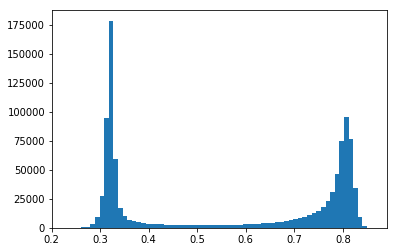

In [21]:
plt.hist(pred[1].flatten(), bins='auto')
plt.show()

In [0]:
threshold = .67
idx = pred < threshold
pred[idx] = 0

In [0]:
b_truth = b_truth.reshape(3,1000,1000)
pred = pred.reshape(3,1000,1000)

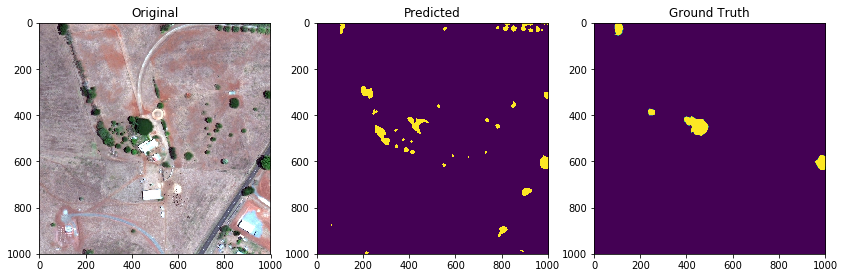

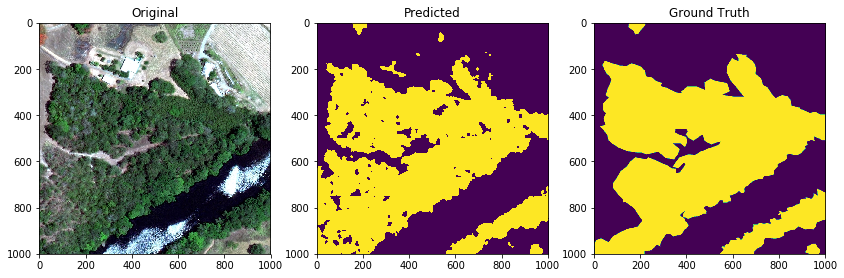

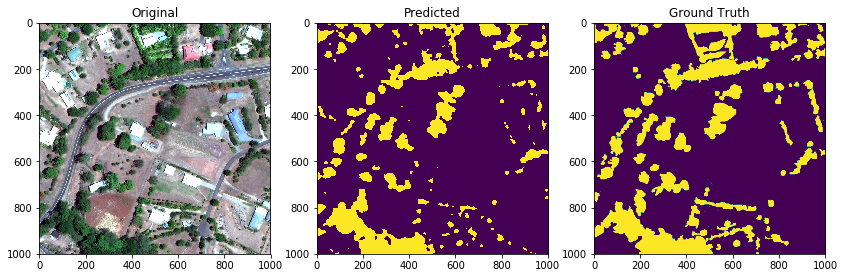

In [25]:
import matplotlib as mlp

default_figsize = mlp.rcParamsDefault['figure.figsize']
mlp.rcParams['figure.figsize'] = [v*2.2 for v in default_figsize]

for i in range(3):
  fig = plt.figure()
  a=fig.add_subplot(1,3,1)
  plt.imshow(original[i])
  a.set_title('Original')
  a=fig.add_subplot(1,3,2)
  plt.imshow(np.round(pred[i]))
  a.set_title('Predicted')
  a=fig.add_subplot(1,3,3)
  plt.imshow(b_truth[i])
  a.set_title('Ground Truth')
  plt.show()